# Scatter plots: cumulative CPI inflation vs demeaned $\xi \times oil$

This notebook plots cumulative quarterly CPI inflation at horizons `0` through `11` against `xi_x_oil`, where `xi` can be demeaned in one of three ways before interacting with quarterly oil price changes:

- two-way demeaned across country and time,
- time demeaned only,
- country demeaned only.

For each horizon `h`, the y-axis is cumulative CPI inflation from `t` through `t+h`.

In [50]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [51]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

demean_mode = "country"  # choose from: "two_way", "time", "country"

horizons = 11
exclude_countries = [
    'AGO', 'ARE', 'ARG', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN',
    'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COL',
    'CRI', 'CZE', 'DNK', 'EGY', 'GBR', 'HKG', 'HUN', 'IDN',
    'IND', 'ISL', 'ISR', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR',
    'LAO', 'MAR', 'MEX', 'MMR', 'MYS', 'NGA', 'NOR', 'NZL',
    'PAK', 'PER', 'PHL', 'POL', 'ROU', 'RUS', 'SAU', 'SEN',
    'SGP', 'STP', 'SWE', 'THA', 'TUN', 'TUR', 'TWN', 'UKR',
    'USA', 'VNM', 'ZAF',
    "SVN", "SVK", "CYP", "MLT", "SVK", "EST", "LTU", "LVA", "HRV"
]
sample_start = 2002
sample_end = None
lag_xi_by_one_year_for_xi_x_oil = True
point_alpha = 0.25
point_size = 12

print("demean_mode:", demean_mode)
print("horizons:", horizons)
print("exclude_countries:", exclude_countries)
print("sample_start:", sample_start)
print("sample_end:", sample_end)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)


demean_mode: country
horizons: 11
exclude_countries: ['AGO', 'ARE', 'ARG', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COL', 'CRI', 'CZE', 'DNK', 'EGY', 'GBR', 'HKG', 'HUN', 'IDN', 'IND', 'ISL', 'ISR', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR', 'LAO', 'MAR', 'MEX', 'MMR', 'MYS', 'NGA', 'NOR', 'NZL', 'PAK', 'PER', 'PHL', 'POL', 'ROU', 'RUS', 'SAU', 'SEN', 'SGP', 'STP', 'SWE', 'THA', 'TUN', 'TUR', 'TWN', 'UKR', 'USA', 'VNM', 'ZAF', 'SVN', 'SVK', 'CYP', 'MLT', 'SVK', 'EST', 'LTU', 'LVA', 'HRV']
sample_start: 2002
sample_end: None
lag_xi_by_one_year_for_xi_x_oil: True


In [52]:
def demean_two_way(df: pd.DataFrame, value_col: str, *, country_col: str = "country", time_col: str = "time_index") -> pd.Series:
    country_mean = df.groupby(country_col)[value_col].transform("mean")
    time_mean = df.groupby(time_col)[value_col].transform("mean")
    grand_mean = df[value_col].mean()
    return df[value_col] - country_mean - time_mean + grand_mean


def demean_time(df: pd.DataFrame, value_col: str, *, time_col: str = "time_index") -> pd.Series:
    time_mean = df.groupby(time_col)[value_col].transform("mean")
    return df[value_col] - time_mean


def demean_country(df: pd.DataFrame, value_col: str, *, country_col: str = "country") -> pd.Series:
    country_mean = df.groupby(country_col)[value_col].transform("mean")
    return df[value_col] - country_mean


def apply_demean_mode(df: pd.DataFrame, value_col: str, mode: str) -> tuple[pd.Series, str]:
    if mode == "two_way":
        return demean_two_way(df, value_col), "two-way demeaned"
    if mode == "time":
        return demean_time(df, value_col), "time demeaned"
    if mode == "country":
        return demean_country(df, value_col), "country demeaned"
    raise ValueError("demean_mode must be one of: 'two_way', 'time', 'country'.")


def add_cumulative_cpi_targets(df: pd.DataFrame, *, y_col: str = "cpi_pct_change", horizons: int = 11) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted
    return out


def fit_line(x: pd.Series, y: pd.Series) -> tuple[np.ndarray, np.ndarray] | tuple[None, None]:
    plot_df = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(plot_df) < 2 or plot_df["x"].nunique() < 2:
        return None, None
    slope, intercept = np.polyfit(plot_df["x"], plot_df["y"], 1)
    x_line = np.linspace(plot_df["x"].min(), plot_df["x"].max(), 200)
    y_line = intercept + slope * x_line
    return x_line, y_line


In [53]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=[],
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

panel_df = panel_df.sort_values(["country", "time_index"]).reset_index(drop=True)
panel_df["xi_demeaned_selected"], demean_label = apply_demean_mode(panel_df, "xi", demean_mode)
panel_df["xi_x_oil_demeaned_selected"] = panel_df["xi_demeaned_selected"] * panel_df["oil_pct_change"]
panel_df = add_cumulative_cpi_targets(panel_df, y_col="cpi_pct_change", horizons=horizons)

x_col = "xi_x_oil_demeaned_selected"
x_label = f"{demean_label} xi x oil"

print("Rows:", len(panel_df))
print("Countries:", panel_df["country"].nunique())
print("Periods:", panel_df["time_index"].nunique())
print("demean label:", demean_label)
panel_df[["country", "period", "xi", "xi_demeaned_selected", "oil_pct_change", "xi_x_oil_demeaned_selected", "cpi_pct_change"]].head(12)


Rows: 1092
Countries: 13
Periods: 84
demean label: country demeaned


,country,period,xi,xi_demeaned_selected,oil_pct_change,xi_x_oil_demeaned_selected,cpi_pct_change
0,AUS,2002-Q1,0.025219,-0.003263,0.077184,-0.000252,0.009284
1,AUS,2002-Q2,0.025219,-0.003263,0.189848,-0.000619,0.006570
2,AUS,2002-Q3,0.025219,-0.003263,0.066242,-0.000216,0.006527
3,AUS,2002-Q4,0.025219,-0.003263,-0.011465,0.000037,0.006485
4,AUS,2003-Q1,0.023971,-0.004511,0.162677,-0.000734,0.012887
5,AUS,2003-Q2,0.023971,-0.004511,-0.167036,0.000754,0.000000
6,AUS,2003-Q3,0.023971,-0.004511,0.068046,-0.000307,0.006361
7,AUS,2003-Q4,0.023971,-0.004511,0.034783,-0.000157,0.005057
8,AUS,2004-Q1,0.029368,0.000886,0.089258,0.000079,0.008805
9,AUS,2004-Q2,0.029368,0.000886,0.102453,0.000091,0.004987


In [54]:
summary_rows = []
for horizon in range(horizons + 1):
    y_col = f"cum_cpi_lead{horizon}"
    plot_df = panel_df[[x_col, y_col]].dropna()
    corr = plot_df[x_col].corr(plot_df[y_col]) if len(plot_df) >= 2 else np.nan
    summary_rows.append(
        {
            "horizon": horizon,
            "rows": len(plot_df),
            "corr": corr,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


,horizon,rows,corr
0,0,1092,0.019211
1,1,1079,0.062641
2,2,1066,0.056924
3,3,1053,0.030559
4,4,1040,-0.027240
5,5,1027,-0.032929
6,6,1014,-0.051797
7,7,1001,-0.040293
8,8,988,-0.028614
9,9,975,-0.021859


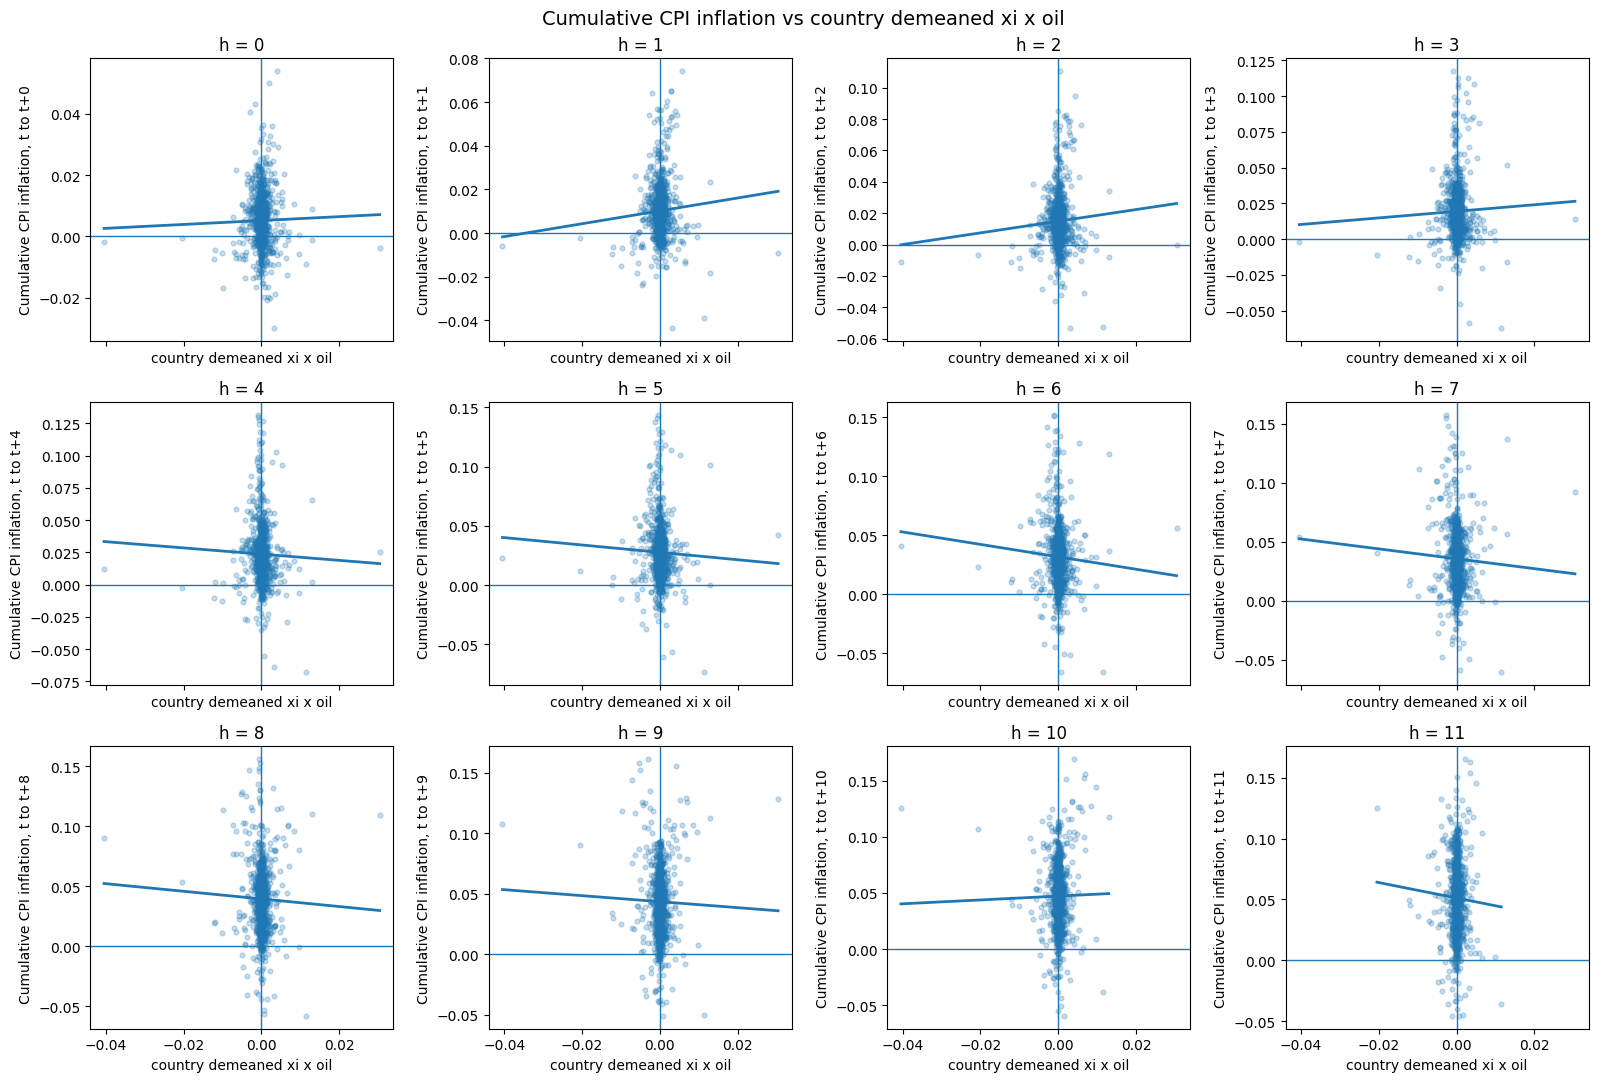

In [55]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.flatten()

for horizon, ax in enumerate(axes[: horizons + 1]):
    y_col = f"cum_cpi_lead{horizon}"
    plot_df = panel_df[[x_col, y_col]].dropna()

    ax.scatter(plot_df[x_col], plot_df[y_col], alpha=point_alpha, s=point_size)
    x_line, y_line = fit_line(plot_df[x_col], plot_df[y_col])
    if x_line is not None:
        ax.plot(x_line, y_line, linewidth=2)

    ax.axhline(0.0, linewidth=1)
    ax.axvline(0.0, linewidth=1)
    ax.set_title(f"h = {horizon}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(f"Cumulative CPI inflation, t to t+{horizon}")

for ax in axes[horizons + 1 :]:
    ax.axis("off")

fig.suptitle(f"Cumulative CPI inflation vs {x_label}", fontsize=14)
plt.tight_layout()
plt.show()


In [56]:
display_cols = [
    "country",
    "period",
    "xi",
    "xi_demeaned_selected",
    "oil_pct_change",
    "xi_x_oil_demeaned_selected",
    "cum_cpi_lead0",
    "cum_cpi_lead1",
    "cum_cpi_lead2",
    "cum_cpi_lead3",
]
panel_df[display_cols].head(12)


,country,period,xi,xi_demeaned_selected,oil_pct_change,xi_x_oil_demeaned_selected,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3
0,AUS,2002-Q1,0.025219,-0.003263,0.077184,-0.000252,0.009284,0.015854,0.022381,0.028867
1,AUS,2002-Q2,0.025219,-0.003263,0.189848,-0.000619,0.006570,0.013098,0.019583,0.032469
2,AUS,2002-Q3,0.025219,-0.003263,0.066242,-0.000216,0.006527,0.013012,0.025899,0.025899
3,AUS,2002-Q4,0.025219,-0.003263,-0.011465,0.000037,0.006485,0.019372,0.019372,0.025733
4,AUS,2003-Q1,0.023971,-0.004511,0.162677,-0.000734,0.012887,0.012887,0.019248,0.024305
5,AUS,2003-Q2,0.023971,-0.004511,-0.167036,0.000754,0.000000,0.006361,0.011418,0.020223
6,AUS,2003-Q3,0.023971,-0.004511,0.068046,-0.000307,0.006361,0.011418,0.020223,0.025211
7,AUS,2003-Q4,0.023971,-0.004511,0.034783,-0.000157,0.005057,0.013862,0.018849,0.022572
8,AUS,2004-Q1,0.029368,0.000886,0.089258,0.000079,0.008805,0.013792,0.017515,0.024931
9,AUS,2004-Q2,0.029368,0.000886,0.102453,0.000091,0.004987,0.008710,0.016126,0.023488
